In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xvzf cifar-10-python.tar.gz

--2026-03-19 21:51:37--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  16.8MB/s    in 11s     

2026-03-19 21:51:48 (15.2 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


We start with (a)

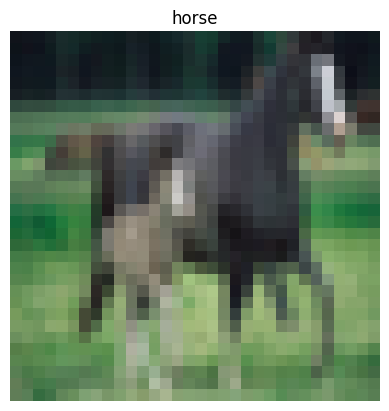

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, model_selection, metrics
import warnings
warnings.filterwarnings('ignore')


def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='latin1')
    return dict

dict1 = unpickle("./cifar-10-batches-py/data_batch_1")
dict2 = unpickle("./cifar-10-batches-py/data_batch_2")
dict3 = unpickle("./cifar-10-batches-py/data_batch_3")
dict4 = unpickle("./cifar-10-batches-py/data_batch_4")
dict5 = unpickle("./cifar-10-batches-py/data_batch_5")
test = unpickle("./cifar-10-batches-py/test_batch")
meta_data = unpickle("./cifar-10-batches-py/batches.meta")
label_names = meta_data["label_names"]


X_train = np.concatenate((dict1["data"],dict2["data"],dict3["data"],dict4["data"],dict5["data"]))
y_train = np.concatenate((dict1["labels"],dict2["labels"],dict3["labels"],dict4["labels"],dict5["labels"]))
X_test = test["data"]
y_test = test["labels"]

def data_to_image(x):
    return(x.reshape(3,32,32).transpose(1,2,0))

def plot_image(image, title=""):
    fig = plt.imshow(data_to_image(image))
    plt.title(title)
    fig.axes.set_axis_off()
    plt.show()

# as a verification that everything is working correctly, plot an image
image_nr = 320
plot_image(X_train[image_nr,:],label_names[y_train[image_nr]])

We transform vectors y_train and y_test to arrays to compute its dimensions

In [ ]:
y_test = np.array(y_test)
y_train = np.array(y_train)

In [ ]:
print("The dimensions of the matrix X_train is: ", X_train.shape, ". The dtype is: ", X_train.dtype )
print("The dimensions of the vector y_train is: ", y_train.shape, ". The dtype is: ", y_train.dtype )
print("The dimensions of the matrix X_test is: ", X_test.shape, ". The dtype is: ", X_test.dtype )
print("The dimensions of the matrix y_test is: ", y_test.shape, ". The dtype is: ", y_test.dtype )

The dimensions of the matrix X_train is:  (50000, 3072) . The dtype is:  uint8
The dimensions of the vector y_train is:  (50000,) . The dtype is:  int64
The dimensions of the matrix X_test is:  (10000, 3072) . The dtype is:  uint8
The dimensions of the matrix y_test is:  (10000,) . The dtype is:  int64


Now, in order to use logistic functions and other functions we will normalize the data. In X_train, for example, we have 50000 different images (n), and 3072 rows which corresponds to red, green and blue channel values (each one consisting of 1024 cells of the matrix). Then, each cell consist of a pixel value between 0 and 255. Then when scaling the data, we will divide by 255 to obtain values between 0 and 1.

In [ ]:
X_train_normalized = X_train/255.0
X_test_normalized = X_test/255.0

Now, we will proceed with (b)

In [ ]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(C = 1, max_iter= 1000, solver='lbfgs')
model1.fit(X_train_normalized, y_train)

acc_train = model1.score(X_train_normalized, y_train)
acc_test = model1.score(X_test_normalized, y_test)

print(f"  Training accuracy : {acc_train:.4f}  ({acc_train*100:.1f}%)")
print(f"  Test accuracy     : {acc_test:.4f}  ({acc_test*100:.1f}%)")

In [ ]:
model2 = LogisticRegression(C = 0.1, max_iter= 1000, solver='lbfgs')
model2.fit(X_train_normalized, y_train)

acc_train = model2.score(X_train_normalized, y_train)
acc_test = model2.score(X_test_normalized, y_test)

print(f"  Training accuracy : {acc_train:.4f}  ({acc_train*100:.1f}%)")
print(f"  Test accuracy     : {acc_test:.4f}  ({acc_test*100:.1f}%)")

In [ ]:
model3 = LogisticRegression(C = 0.01, max_iter= 1000, solver='lbfgs')
model3.fit(X_train_normalized, y_train)

acc_train = model3.score(X_train_normalized, y_train)
acc_test = model3.score(X_test_normalized, y_test)

print(f"  Training accuracy : {acc_train:.4f}  ({acc_train*100:.1f}%)")
print(f"  Test accuracy     : {acc_test:.4f}  ({acc_test*100:.1f}%)")

We continue with (c)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

#we select 12 values for C in the range [1e-4,100]
C_values = np.logspace(-4,1,12)

#in order to do cross-validation with K = 4 folds, we set cv = 4
model2 = LogisticRegressionCV(Cs = C_values, solver = 'lbfgs', max_iter = 1000, cv = 4, n_jobs = -1)
model2.fit(X_train_normalized, y_train)

LogisticRegressionCV(Cs=array([1.00000000e-04, 2.84803587e-04, 8.11130831e-04, 2.31012970e-03,
       6.57933225e-03, 1.87381742e-02, 5.33669923e-02, 1.51991108e-01,
       4.32876128e-01, 1.23284674e+00, 3.51119173e+00, 1.00000000e+01]),
                     cv=4, max_iter=1000, n_jobs=-1)

Now, to find the scores for the different values of C_values, we need to use one of the attributes that return the function LogisticRegressionCV. In particular, we use the scores_ one, which returns a dict with classes as the keys, and the values as the grid of scores obtained during cross-validating each fold. In particular, each value is an array of shape (n_folds, n_Cs).

In [ ]:
scores_model2_raw = np.array(list(model2.scores_.values())) #returns an array of dimensions (10,4,12), i.e. (number of classes, number of folds, number of C_values)
scores_model2 = scores_model2_raw.mean(axis = 0).mean(axis = 0) #for each class, we do the mean for the different number of folds and the different number of classes. The result is an array with dimensions (number of C_values)

best_C_value = model2.C_[0] #returns the value of C that maps to the best score, repeated n_classes times, then, we only select one, for example the one corresponding to the first class.
print(f"  Best C: {best_C_value:.5f}")

  Best C: 0.00658


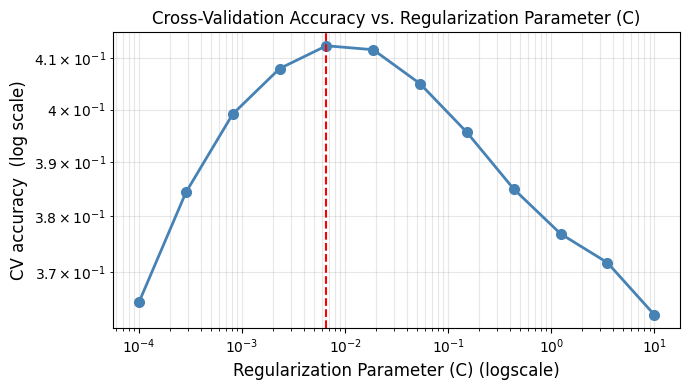

In [ ]:
plt.figure(figsize = (7,4))
plt.loglog(C_values, scores_model2, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.axvline(best_C_value, color='red', linestyle='--', linewidth=1.5,
            label=f'Best C = {best_C_value:.4f}')
plt.xlabel('Regularization Parameter (C) (logscale)', fontsize=12)
plt.ylabel('CV accuracy  (log scale)', fontsize=12)
plt.title('Cross-Validation Accuracy vs. Regularization Parameter (C)')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

We continue with (d)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

'''
With KFold, some folds may have less samples of some classes, making the cross validation noisy (introducing bias).

However, StratifiedKFold guarantees us that each fold has the same class proportions as the original dataset
'''

kf = StratifiedKFold(n_splits = 4, shuffle = True)

C_values = np.logspace(-4,1,12)

log_losses = []

for c in C_values:
  model = LogisticRegression(C = c, max_iter = 1000, solver = 'lbfgs')
  y_pred_probab = cross_val_predict(model, X_train_normalized, y_train, cv = kf, method = 'predict_proba', n_jobs = -1)

  loss = log_loss(y_train, y_pred_probab)
  log_losses.append(loss)

best_C_value_logloss = C_values[np.argmin(log_losses)]
print(f"\Optimal C_value based on Log Loss: {best_C_value_logloss:.5f}")

\Optimal C_value based on Log Loss: 0.01874


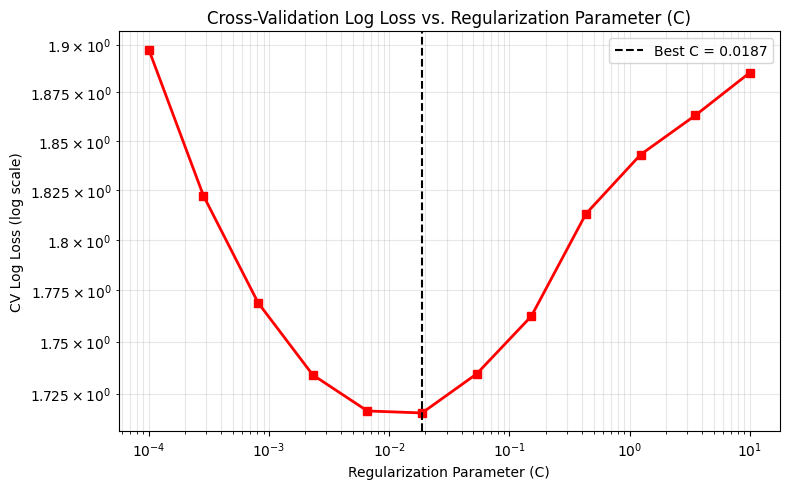

In [ ]:
plt.figure(figsize = (8,5))
plt.plot(C_values, log_losses, marker='s', color='red', linewidth=2)
plt.axvline(best_C_value_logloss, color='black', linestyle='--', linewidth=1.5,
            label=f'Best C = {best_C_value_logloss:.4f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('CV Log Loss (log scale)')
plt.title('Cross-Validation Log Loss vs. Regularization Parameter (C)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Now, we continue with (e)

In [ ]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression

optimal_C1 = 0.00658 #the one obtained from (c)

final_model1 = LogisticRegression(C = optimal_C1, max_iter = 1000, solver = 'lbfgs', n_jobs = -1)

final_model1.fit(X_train_normalized, y_train)


#now we compute predictions and probabilities for test and train sets

train_pred = final_model1.predict(X_train_normalized)
train_proba = final_model1.predict_proba(X_train_normalized)

test_pred = final_model1.predict(X_test_normalized)
test_proba = final_model1.predict_proba(X_test_normalized)

print(f"--- Results for Optimal C = {optimal_C1} ---")
print(f"Train Accuracy: {accuracy_score(y_train, train_pred):.4f}")
print(f"Train Log Loss: {log_loss(y_train, train_proba):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Test Log Loss:  {log_loss(y_test, test_proba):.4f}")

--- Results for Optimal C = 0.00658 ---
Train Accuracy: 0.4458
Train Log Loss: 1.6487
Test Accuracy:  0.4164
Test Log Loss:  1.7026


In [ ]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression

optimal_C2 = 0.01874 #the one obtained from (d)

final_model2 = LogisticRegression(C = optimal_C2, max_iter = 1000, solver = 'lbfgs', n_jobs = -1)

final_model2.fit(X_train_normalized, y_train)


#now we compute predictions and probabilities for test and train sets

train_pred = final_model2.predict(X_train_normalized)
train_proba = final_model2.predict_proba(X_train_normalized)

test_pred = final_model2.predict(X_test_normalized)
test_proba = final_model2.predict_proba(X_test_normalized)

print(f"--- Results for Optimal C = {optimal_C2} ---")
print(f"Train Accuracy: {accuracy_score(y_train, train_pred):.4f}")
print(f"Train Log Loss: {log_loss(y_train, train_proba):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Test Log Loss:  {log_loss(y_test, test_proba):.4f}")

--- Results for Optimal C = 0.01874 ---
Train Accuracy: 0.4580
Train Log Loss: 1.6141
Test Accuracy:  0.4177
Test Log Loss:  1.7047


In [ ]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression

optimal_C3 = (0.01874+0.00658)/2 #the one obtained from (d)

final_model3 = LogisticRegression(C = optimal_C3, max_iter = 1000, solver = 'lbfgs', n_jobs = -1)

final_model3.fit(X_train_normalized, y_train)


#now we compute predictions and probabilities for test and train sets

train_pred = final_model3.predict(X_train_normalized)
train_proba = final_model3.predict_proba(X_train_normalized)

test_pred = final_model3.predict(X_test_normalized)
test_proba = final_model3.predict_proba(X_test_normalized)

print(f"--- Results for Optimal C = {optimal_C3} ---")
print(f"Train Accuracy: {accuracy_score(y_train, train_pred):.4f}")
print(f"Train Log Loss: {log_loss(y_train, train_proba):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, test_pred):.4f}")
print(f"Test Log Loss:  {log_loss(y_test, test_proba):.4f}")

--- Results for Optimal C = 0.01266 ---
Train Accuracy: 0.4539
Train Log Loss: 1.6265
Test Accuracy:  0.4182
Test Log Loss:  1.7022
